In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
def get_results(base, mod, v, input_type):
    preds = []
    for vid in test_vids:
        #print(base.format(mod, v, vid))
        p = np.load(base.format(mod, input_type, v, vid))
        p = p.argmax(axis=1)
        preds += list(p)
    preds = np.array(preds)
    return preds

def get_f1_dict(suffix='states'):
    mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-19/dtcn/{}-21-good_sample-0_{}/version_{}/{}_states.npy'
    f1_meta = {}
    mods = [('left21', 'markers2'), ('right21', 'markers_r')]

    for mod, input_type in mods:
        f1_meta[mod] = []
        for v in range(5):
            preds = get_results(mod_base, mod,v, input_type)
            f1 = f1_score(states[states>0], preds[states>0], average=None)
            f1_meta[mod].append([np.mean(f1)] + list(f1))

            
    # aggregate results
    f1_plot = {}
    for mod, input_type in mods:
        mean_list = []
        sd_list = []
        for p in range(len(labels)):
            mean = np.mean([a[p] for a in f1_meta[mod]])
            sd = np.std([a[p] for a in f1_meta[mod]])/np.sqrt(5)
            mean_list.append(mean)
            sd_list.append(sd)
        f1_plot[mod] = (mean_list, sd_list)


    f1_ens = get_ens_mode()
    for key, preds in f1_ens.items():
        f1= f1_score(states[states>0], preds, average=None)
        val = [np.mean(f1)] + list(f1)
        f1_plot[key+'_ens'] =(val, np.zeros_like(val))
        
    return f1_plot


def get_ens_mode(labeled_only=True):
    mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-19/dtcn/{}-21-good_sample-0_{}/version_{}/{}_states.npy'
    all_modes = {}
    for mod, input_type in mods:
        temp_preds = []
        for v in range(5):
            preds = get_results(mod_base, mod,v, input_type)
            if labeled_only:
                preds = preds[states>0]
            temp_preds.append(preds)
            
        # modes
        stacked_arrays = np.array(temp_preds)
        modes = stats.mode(stacked_arrays, axis=0).mode.reshape(-1)#[0][0]
        all_modes[mod] = modes
            
    return all_modes
    
def plot_f1(f1_plot, it='regular markers'):
    # Numbers of pairs of bars you want
    N = len(label_names)
    # Position of bars on x-axis
    ind = np.arange(N)

    colors = ['black', 'grey', 'lightgrey', 'slategrey', 'peru', 'brown']
    # Figure size
    plt.figure(figsize=(8,5))

    # Width of a bar 
    width = 0.15     
    i=0
    for mod, (mean, sd) in f1_plot.items():
        #if i==0:
        print(mod, np.round(mean,3))
        # Plotting
        label = mod
        if mod == 'nope':
            label='none'
        plt.bar(ind + width*i, mean, width, label=label, color=colors[i],yerr=sd)
        plt.xlabel('classes')
        plt.ylabel('F1 score')
        plt.title('F1 scores from different cameras')

        # xticks()
        # First argument - A list of positions at which ticks should be placed
        # Second argument -  A list of labels to place at the given locations
        plt.xticks(ind + width, label_names)
        i+=1

    # Finding the best position for legends and putting it
    plt.legend(loc='best')
    plt.show()

In [3]:
# test_vids = [
#     'churchlandlab_CSHL045_2020-02-27-001',
#     'cortexlab_KS020_2020-02-06-001',
#     'hoferlab_SWC_043_2020-09-15-001',
#     'mrsicflogellab_SWC_052_2020-10-22-001',
#     'wittenlab_ibl_witten_27_2021-01-21-001',
# ]
from daart_utils.session_ids.ibl import SESS_IDS_TEST_5_V2 as test_vids
label_names = ['avg', 'still', 'move', 'wheel_turn', 'groom']

In [4]:
# load gt labels
base = '/home/bsb2144/daart_utils/data/ibl/labels-hand/{}_labels.csv'
labels = {}
states = []
for vid in test_vids:
    labs = pd.read_csv(base.format(vid),index_col=0).to_numpy()
    labs = labs.argmax(axis=1)
    states += list(labs)
    labels[vid] = labs
states = np.array(states)

In [5]:
# # graph accuracy
# suffix='states'
# mod_base = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/{}_' + suffix + '.npy'
# mods = ['nope', 'all', 'rotate', 'shift', 'gauss', 'shot']
# gt = states[states>0]
# for mod in mods:
#     print(mod)
#     for v in range(5):
#         p=get_results(mod_base, mod, v)[states>0]
#         acc = accuracy_score(gt,p)
#         print(acc)
mods = [('left21', 'markers2'), ('right21', 'markers_r')]

In [6]:
f1_plot = get_f1_dict()

left21 [0.904 0.945 0.808 0.867 0.995]
right21 [0.837 0.885 0.668 0.819 0.974]
left21_ens [0.909 0.945 0.819 0.877 0.996]
right21_ens [0.845 0.892 0.683 0.828 0.978]


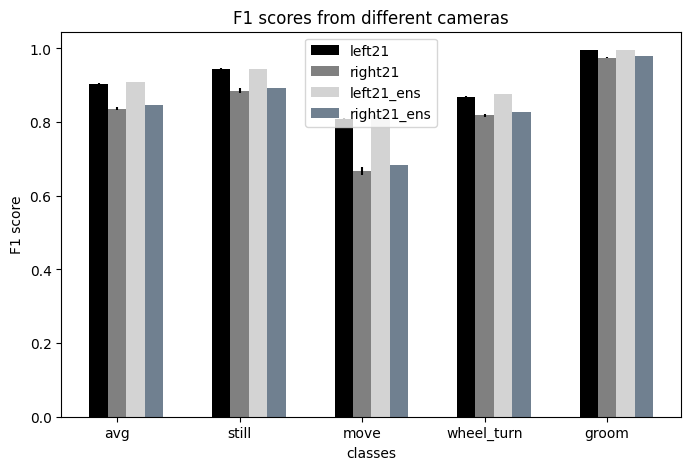

In [7]:
plot_f1(f1_plot)

In [27]:
# reg model
import os
import yaml
import torch
from daart.models import Segmenter
from daart.data import DataGenerator, compute_sequence_pad
from daart.eval import get_precision_recall, run_lengths
from daart.io import get_expt_dir, find_experiment
from daart.transforms import ZScore
from daart_utils.data import DataHandler
from daart_utils.models import compute_model_predictions, get_default_hparams

input_type_mod = 'features-vit_m_17'
spec = "lr=1e-05_dropout=0.1_n_hid_units=32_n_lags=8_n_hid_layers=2"

data_path = '/home/bsb2144/daart_utils/data/ibl'
mod_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/dtcn/{}-18-good_sample-0_{}/version_{}/'
vid_path = '/home/bsb2144/daart_utils/data/ibl/{}/{}_labeled.csv'
mods = [('og20', 'markers2'), ('right20', 'markers_r')]

save_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/dtcn/{}-18-good_sample-0_{}/version_{}/{}_states.npy'
#input_type = 'markers-smooth'
#input_type = 'fpv-new'
#f-new

for mod, input_type in mods:
    for v in range(5):
        model_dir = mod_path.format(mod,input_type, v)
        # load model
        model_file = os.path.join(model_dir, 'last_model.pt')
        arch_file = os.path.join(model_dir, 'hparams.yaml')

        print('Loading model defined in %s' % arch_file)
        with open(arch_file, 'rb') as f:
            hparams_new = yaml.safe_load(f)
        model_0 = Segmenter(hparams_new)
        model_0.load_state_dict(torch.load(model_file, map_location=lambda storage, loc: storage))
        model_0.to(hparams_new['device'])
        model_0.eval()
        
        # inf and save res
        for expt_id in test_vids:
            markers_file = vid_path.format(input_type, expt_id)
            hand_labels_file = os.path.join(data_path, 'labels-hand', expt_id + '_labels.csv')
            # define data generator signals
            signals = ['markers']
            transforms = [ZScore()]
            paths = [markers_file]
            print(markers_file)
            # build data generator
            data_gen_test = DataGenerator(
                [expt_id], [signals], [transforms], [paths], device=hparams_new['device'], 
                batch_size=hparams_new['batch_size'], trial_splits='9;1;0;0', #'1;1;0;0', 
                sequence_pad=hparams_new['sequence_pad'], sequence_length=hparams_new['sequence_length'],
                input_type=input_type)
            print(data_gen_test)
            tmp = model_0.predict_labels(data_gen_test, return_scores=True)
            labels_pred = np.vstack(tmp['labels'][0])#[:100000]
            
            # save preds
            save_to = save_path.format(mod, input_type, v, expt_id)
            np.save(save_to, labels_pred)

Loading model defined in /home/bsb2144/daart/results_daart/ibl/multi-18/dtcn/og20-20-good_sample-0_markers2/version_0/hparams.yaml
/home/bsb2144/daart_utils/data/ibl/markers2/1b715600-0cbc-442c-bd00-5b0ac2865de1_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/ibl/markers2/1b715600-0cbc-442c-bd00-5b0ac2865de1_labeled.csv
Generator contains 1 SingleDataset objects:
1b715600-0cbc-442c-bd00-5b0ac2865de1
    signals: ['markers']
    transforms: OrderedDict([('markers', ZScore())])
    paths: OrderedDict([('markers', '/home/bsb2144/daart_utils/data/ibl/markers2/1b715600-0cbc-442c-bd00-5b0ac2865de1_labeled.csv')])

/home/bsb2144/daart_utils/data/ibl/markers2/3bcb81b4-d9ca-4fc9-a1cd-353a966239ca_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/ibl/markers2/3bcb81b4-d9ca-4fc9-a1cd-353a966239ca_labeled.csv
Generator contains 1 SingleDataset objects:
3bcb81b4-d9ca-4fc9-a1cd-353a966239ca
    signals: ['markers']
    transforms: OrderedDict([('markers', ZScore())])
    paths: Order

In [1]:
# calms21
import os
import yaml
import numpy as np
import torch
from daart.models import Segmenter
from daart.data import DataGenerator, compute_sequence_pad
#from daart.eval import get_precision_recall, run_lengths
from daart.io import get_expt_dir, find_experiment
from daart.transforms import ZScore
from daart_utils.data import DataHandler
from daart_utils.models import compute_model_predictions, get_default_hparams
from daart_utils.session_ids.ibl import SESS_IDS_TEST_5_V2 as test_vids
from daart.utils import build_data_generator

#kp_100-18-good_sample-0_markers_100_np
vs = 5
input_type_mod = input_type = "features-simba"
#'transformer'

specs = [
    "wv2",
]

data_path = '/home/bsb2144/daart_utils/data/calms21'
mod_path = '/home/bsb2144/daart/results_daart/calms21/multi-0/dtcn/{}-68-good_sample-0_{}/version_{}/'
#mod_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/temporal-mlp/{}-18-good_sample-0_{}/version_{}/'
vid_path = '/home/bsb2144/daart_utils/data/ibl/{}/{}_labeled.npy'

#save_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/temporal-mlp/{}-18-good_sample-0_{}/version_{}/{}_states.npy'
save_path = '/home/bsb2144/daart/results_daart/calms21/multi-0/dtcn/{}-68-good_sample-0_{}/version_{}/{}_states_end.npy'
print('hi')
for spec in specs:
    for v in range(vs):
        model_dir = mod_path.format(spec,input_type, v)
        # load model
        #model_file = os.path.join(model_dir, 'best_val_model.pt')
        model_file = os.path.join(model_dir, 'last_model.pt')
        arch_file = os.path.join(model_dir, 'hparams.yaml')

        print('Loading model defined in %s' % arch_file)
        with open(arch_file, 'rb') as f:
            hparams_new = yaml.safe_load(f)
        model = Segmenter(hparams_new)
        model.load_state_dict(torch.load(model_file, map_location=lambda storage, loc: storage))
        model.to(hparams_new['device'])
        model.eval()
        
        data_gen = build_data_generator(hparams_new, dtype='test')
        results_dict = model.predict_labels(data_gen)
        for sess, dataset in enumerate(data_gen.datasets):
            expt_id = dataset.id
            print('expt id', expt_id)
            labels = np.vstack(results_dict['labels'][sess])
            print('l', labels.shape, labels[0])
            np.save(save_path.format(spec, input_type, v, expt_id), labels)


hi
Loading model defined in /home/bsb2144/daart/results_daart/calms21/multi-0/dtcn/wv2-68-good_sample-0_features-simba/version_0/hparams.yaml
Reading file: /home/bsb2144/daart_utils/data/calms21/features-simba/mouse071_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/calms21/features-simba/mouse072_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/calms21/features-simba/mouse073_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/calms21/features-simba/mouse074_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/calms21/features-simba/mouse075_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/calms21/features-simba/mouse076_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/calms21/features-simba/mouse077_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/calms21/features-simba/mouse078_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/calms21/features-simba/mouse079_labeled.csv
Reading file: /home/bsb2144/daart_utils/data/calms21/feat

In [1]:
# transformer model cm
import os
import yaml
import numpy as np
import torch
from daart.models import Segmenter
from daart.data import DataGenerator, compute_sequence_pad
#from daart.eval import get_precision_recall, run_lengths
from daart.io import get_expt_dir, find_experiment
from daart.transforms import ZScore
from daart_utils.data import DataHandler
from daart_utils.models import compute_model_predictions, get_default_hparams
from daart_utils.session_ids.ibl import SESS_IDS_TEST_5_V2 as test_vids
from daart.utils import build_data_generator

#kp_100-18-good_sample-0_markers_100_np
vs = 5
input_type = 'transformer'

specs = [
    "td"  
]

input_types = [
    # "markers_100_np",
    # "markers_500_np",
    # "markers_1000_np",
    # "markers_5000_np",
    # "features-markers_no_wheel",

    #"features-pca_wheel",
    # "features-vit_mae",
    # "features-vit_m_new",
    #"features-vit_cm_new_wheel",

    'transformer'
]



data_path = '/home/bsb2144/daart_utils/data/ibl'
mod_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/dtcn/{}-18-good_sample-0_{}/version_{}/'
#mod_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/temporal-mlp/{}-18-good_sample-0_{}/version_{}/'
vid_path = '/home/bsb2144/daart_utils/data/ibl/{}/{}_labeled.npy'

#save_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/temporal-mlp/{}-18-good_sample-0_{}/version_{}/{}_states_end.npy'
save_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/dtcn/{}-18-good_sample-0_{}/version_{}/{}_states.npy'

for input_type in input_types:
    for spec in specs:
        for v in range(vs):
            model_dir = mod_path.format(spec,input_type, v)
            # load model
            model_file = os.path.join(model_dir, 'best_val_model.pt')
            #model_file = os.path.join(model_dir, 'last_model.pt')
            arch_file = os.path.join(model_dir, 'hparams.yaml')
    
            print('Loading model defined in %s' % arch_file)
            with open(arch_file, 'rb') as f:
                hparams_new = yaml.safe_load(f)
            model = Segmenter(hparams_new)
            model.load_state_dict(torch.load(model_file, map_location=lambda storage, loc: storage))
            model.to(hparams_new['device'])
            model.eval()
            
            data_gen = build_data_generator(hparams_new, dtype='test')
            results_dict = model.predict_labels_vit(data_gen)
            print("results_dict['labels']", results_dict['labels'])
            for sess, dataset in enumerate(data_gen.datasets):
                expt_id = dataset.id
                print('expt id', expt_id)
                labels = np.vstack(results_dict['labels'][sess])
                print('l', labels.shape, labels[0])
                np.save(save_path.format(spec, input_type, v, expt_id), labels)


Loading model defined in /home/bsb2144/daart/results_daart/ibl/multi-22/dtcn/td-18-good_sample-0_transformer/version_0/hparams.yaml
Saved:
  /home/bsb2144/daart_utils/data/ibl/dali_seq/video_list_test.txt
  /home/bsb2144/daart_utils/data/ibl/dali_seq/labels_list_test.txt


[/opt/dali/dali/operators/image/crop/new_crop_mirror_normalize.cu:249] using CropMirrorNormalize legacy implementation


KeyError: 'labels'

In [3]:
# real t
import os
import yaml
import numpy as np
import torch
from daart.models import Segmenter
from daart.data import DataGenerator, compute_sequence_pad
#from daart.eval import get_precision_recall, run_lengths
from daart.io import get_expt_dir, find_experiment
from daart.transforms import ZScore
from daart_utils.data import DataHandler
from daart_utils.models import compute_model_predictions, get_default_hparams
from daart_utils.session_ids.ibl import SESS_IDS_TEST_5_V2 as test_vids
from daart.utils import build_data_generator

#kp_100-18-good_sample-0_markers_100_np
vs = 1
input_type = 'transformer'

specs = [
    "td"  
]

input_types = [
    # "markers_100_np",
    # "markers_500_np",
    # "markers_1000_np",
    # "markers_5000_np",
    # "features-markers_no_wheel",

    #"features-pca_wheel",
    # "features-vit_mae",
    # "features-vit_m_new",
    #"features-vit_cm_new_wheel",

    'transformer'
]



data_path = '/home/bsb2144/daart_utils/data/ibl'
mod_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/dtcn/{}-18-good_sample-0_{}/version_{}/'
#mod_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/temporal-mlp/{}-18-good_sample-0_{}/version_{}/'
vid_path = '/home/bsb2144/daart_utils/data/ibl/{}/{}_labeled.npy'

#save_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/temporal-mlp/{}-18-good_sample-0_{}/version_{}/{}_states_end.npy'
save_path = '/home/bsb2144/daart/results_daart/ibl/multi-22/dtcn/{}-18-good_sample-0_{}/version_{}/{}_states.npy'

for input_type in input_types:
    for spec in specs:
        for v in range(vs):
            model_dir = mod_path.format(spec,input_type, v)
            # load model
            model_file = os.path.join(model_dir, 'best_val_model.pt')
            #model_file = os.path.join(model_dir, 'last_model.pt')
            arch_file = os.path.join(model_dir, 'hparams.yaml')
    
            print('Loading model defined in %s' % arch_file)
            with open(arch_file, 'rb') as f:
                hparams_new = yaml.safe_load(f)
            model = Segmenter(hparams_new)
            model.load_state_dict(torch.load(model_file, map_location=lambda storage, loc: storage))
            model.to(hparams_new['device'])
            model.eval()
            
            data_gen = build_data_generator(hparams_new, dtype='test')
            #results_dict = model.predict_labels_vit(data_gen)
            #print("results_dict", results_dict)
            for sess, expt_id in enumerate(test_vids):
                #expt_id = dataset.id
                print('expt id', expt_id)
                labels = np.vstack(results_dict[expt_id]['labels']).reshape(-1)
                print('l', labels.shape, labels[:500])
                np.save(save_path.format(spec, input_type, v, expt_id), labels)


Loading model defined in /home/bsb2144/daart/results_daart/ibl/multi-22/dtcn/td-18-good_sample-0_transformer/version_0/hparams.yaml
Saved:
  /home/bsb2144/daart_utils/data/ibl/dali_seq/video_list_test.txt
  /home/bsb2144/daart_utils/data/ibl/dali_seq/labels_list_test.txt
expt id 3f859b5c-e73a-4044-b49e-34bb81e96715
l (100000,) [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

[0.9072175174681929, 0.9511768450581762, 0.7991522442944576, 0.8926239676021371, 0.985917012918]


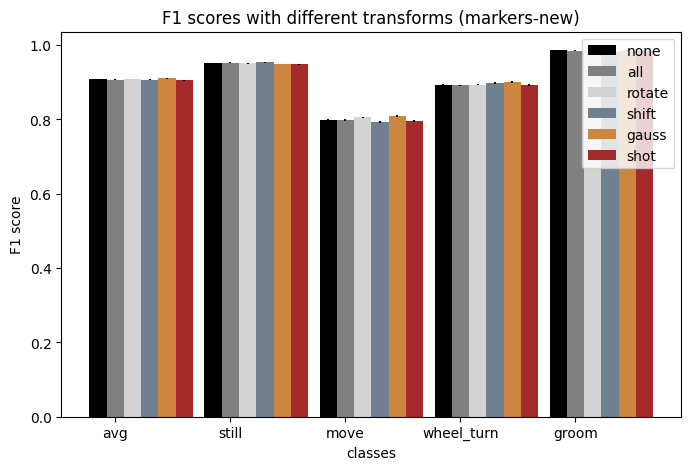

In [32]:
it = 'markers-new'
f1_plot_new = get_f1_dict(it)
plot_f1(f1_plot_new, it)

In [9]:
print(len(results_dict['labels']))
labels = 

497
(2, 500, 1)


[0.9035633496533894, 0.9470296932665463, 0.7907469683631463, 0.8900248780374543, 0.9864518589464109]


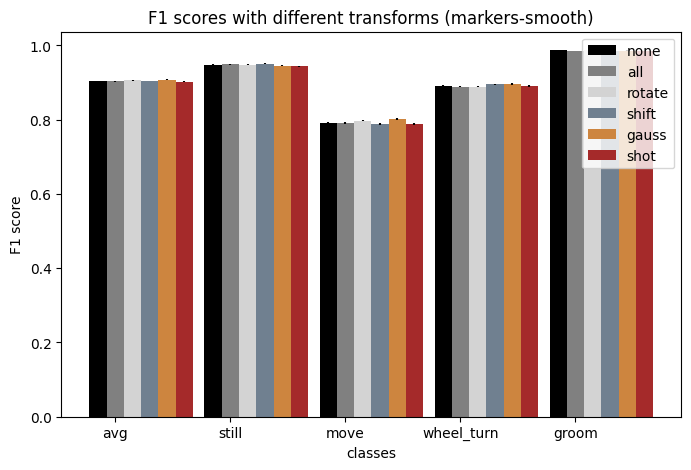

In [33]:
it = 'markers-smooth'
f1_plot_smooth = get_f1_dict(it)
plot_f1(f1_plot_smooth, it)

# Save predicitons on markers-new and markers-smooth data

In [5]:
# inf on other session types

test_vids = [
    'churchlandlab_CSHL045_2020-02-27-001',
    'cortexlab_KS020_2020-02-06-001',
    'hoferlab_SWC_043_2020-09-15-001',
    'mrsicflogellab_SWC_052_2020-10-22-001',
    'wittenlab_ibl_witten_27_2021-01-21-001',
]
# vid_map = {
#     '46794e05-3f6a-4d35-afb3-9165091a5a74': 'churchlandlab_CSHL045_2020-02-27-001',
#     'c7b0e1a3-4d4d-4a76-9339-e73d0ed5425b': 'cortexlab_KS020_2020-02-06-001',
#     #'db4df448-e449-4a6f-a0e7-288711e7a75a': ‘danlab_DY_009_2020-02-27-001’,
#     #'54238fd6-d2d0-4408-b1a9-d19d24fd29ce': ‘danlab_DY_018_2020-10-15-001’,
#     'f3ce3197-d534-4618-bf81-b687555d1883': 'hoferlab_SWC_043_2020-09-15-001',
#     #'493170a6-fd94-4ee4-884f-cc018c17eeb9': ‘hoferlab_SWC_061_2020-11-23-001’,
#     '7cb81727-2097-4b52-b480-c89867b5b34c': 'mrsicflogellab_SWC_052_2020-10-22-001',
#     #'1735d2be-b388-411a-896a-60b01eaa1cfe': ‘mrsicflogellab_SWC_058_2020-12-11-001’,
#     #'ff96bfe1-d925-4553-94b5-bf8297adf259': ‘wittenlab_ibl_witten_26_2021-01-27-002’,
#     '73918ae1-e4fd-4c18-b132-00cb555b1ad2': 'wittenlab_ibl_witten_27_2021-01-21-001'
# }



In [6]:
vid_map = {
    'churchlandlab_CSHL045_2020-02-27-001': '46794e05-3f6a-4d35-afb3-9165091a5a74',
    'cortexlab_KS020_2020-02-06-001': 'c7b0e1a3-4d4d-4a76-9339-e73d0ed5425b',
    'hoferlab_SWC_043_2020-09-15-001': 'f3ce3197-d534-4618-bf81-b687555d1883',
    'mrsicflogellab_SWC_052_2020-10-22-001': '7cb81727-2097-4b52-b480-c89867b5b34c',
    'wittenlab_ibl_witten_27_2021-01-21-001': '73918ae1-e4fd-4c18-b132-00cb555b1ad2'
}

def get_marker_file(vid, input_type):
    file_name = vid_map[vid]
    file_path = vid_path.format(input_type, file_name)
    return file_path


In [34]:
test_vids = [
    'db4df448-e449-4a6f-a0e7-288711e7a75a',  # Berkeley
    'd23a44ef-1402-4ed7-97f5-47e9a7a504d9',  # Berkeley
    '4a45c8ba-db6f-4f11-9403-56e06a33dfa4',  # Berkeley
    'e535fb62-e245-4a48-b119-88ce62a6fe67',  # Berkeley
    '54238fd6-d2d0-4408-b1a9-d19d24fd29ce',  # Berkeley
    'b03fbc44-3d8e-4a6c-8a50-5ea3498568e0',  # Berkeley
    '30c4e2ab-dffc-499d-aae4-e51d6b3218c2',  # CCU
    'd0ea3148-948d-4817-94f8-dcaf2342bbbe',  # CCU
    'a4a74102-2af5-45dc-9e41-ef7f5aed88be',  # CCU
    '746d1902-fa59-4cab-b0aa-013be36060d5',  # CCU
    '88224abb-5746-431f-9c17-17d7ef806e6a',  # CCU
    '0802ced5-33a3-405e-8336-b65ebc5cb07c',  # CCU
    'ee40aece-cffd-4edb-a4b6-155f158c666a',  # CCU
    'c7248e09-8c0d-40f2-9eb4-700a8973d8c8',  # CCU
    '72cb5550-43b4-4ef0-add5-e4adfdfb5e02',  # CCU
    'dda5fc59-f09a-4256-9fb5-66c67667a466',  # CSHL(C)
    '4b7fbad4-f6de-43b4-9b15-c7c7ef44db4b',  # CSHL(C)
    'f312aaec-3b6f-44b3-86b4-3a0c119c0438',  # CSHL(C)
    '4b00df29-3769-43be-bb40-128b1cba6d35',  # CSHL(C)
    'ecb5520d-1358-434c-95ec-93687ecd1396',  # CSHL(C)
    '51e53aff-1d5d-4182-a684-aba783d50ae5',  # NYU
    'f140a2ec-fd49-4814-994a-fe3476f14e66',  # NYU
    'a8a8af78-16de-4841-ab07-fde4b5281a03',  # NYU
    '61e11a11-ab65-48fb-ae08-3cb80662e5d6',  # NYU
    '73918ae1-e4fd-4c18-b132-00cb555b1ad2',  # Princeton
    'd9f0c293-df4c-410a-846d-842e47c6b502',  # Princeton
    'dac3a4c1-b666-4de0-87e8-8c514483cacf',  # SWC(H)
    '6f09ba7e-e3ce-44b0-932b-c003fb44fb89',  # SWC(H)
    '56b57c38-2699-4091-90a8-aba35103155e',  # SWC(M)
    '3638d102-e8b6-4230-8742-e548cd87a949',  # SWC(M)
    '7cb81727-2097-4b52-b480-c89867b5b34c',  # SWC(M)
    '781b35fd-e1f0-4d14-b2bb-95b7263082bb',  # UCL
    '3f859b5c-e73a-4044-b49e-34bb81e96715',  # UCL
    'b22f694e-4a34-4142-ab9d-2556c3487086',  # UCL
    '0a018f12-ee06-4b11-97aa-bbbff5448e9f',  # UCL
    'aad23144-0e52-4eac-80c5-c4ee2decb198',  # UCL
    'b196a2ad-511b-4e90-ac99-b5a29ad25c22',  # UCL
    'e45481fa-be22-4365-972c-e7404ed8ab5a',  # UCL
    'd04feec7-d0b7-4f35-af89-0232dd975bf0',  # UCL
    '1b715600-0cbc-442c-bd00-5b0ac2865de1',  # UCL
    'c7bf2d49-4937-4597-b307-9f39cb1c7b16',  # UCL
    '8928f98a-b411-497e-aa4b-aa752434686d',  # UCL
    'ebce500b-c530-47de-8cb1-963c552703ea',  # UCLA
    'dc962048-89bb-4e6a-96a9-b062a2be1426',  # UCLA
    '6899a67d-2e53-4215-a52a-c7021b5da5d4',  # UCLA
    '15b69921-d471-4ded-8814-2adad954bcd8',  # UCLA
    '5ae68c54-2897-4d3a-8120-426150704385',  # UCLA
    'ca4ecb4c-4b60-4723-9b9e-2c54a6290a53',  # UCLA
    '824cf03d-4012-4ab1-b499-c83a92c5589e',  # UCLA
    '3bcb81b4-d9ca-4fc9-a1cd-353a966239ca',  # UW
    'f115196e-8dfe-4d2a-8af3-8206d93c1729',  # UW
    '9b528ad0-4599-4a55-9148-96cc1d93fb24',  # UW
    '3e6a97d3-3991-49e2-b346-6948cb4580fb',  # UW
]

In [35]:
# reg model
import os
import yaml
import torch
from daart.models import Segmenter
from daart.data import DataGenerator, compute_sequence_pad
from daart.eval import get_precision_recall, run_lengths
from daart.io import get_expt_dir, find_experiment
from daart.transforms import ZScore
from daart_utils.data import DataHandler
from daart_utils.models import compute_model_predictions, get_default_hparams

input_type_mod = 'features-posvel'
data_path = '/home/bsb2144/daart_utils/data/ibl'
mod_path = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_'+ input_type_mod + '/version_{}/'
vid_path = '/home/bsb2144/daart_utils/data/ibl/{}/{}_labeled.csv'
mods = ['nope', 'all', 'rotate', 'shift', 'gauss', 'shot']

save_path = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_'+ input_type_mod + '/version_{}/{}_{}.npy'
#input_type = 'markers-smooth'
input_type = 'fpv-new'
#f-new

for mod in mods:
    for v in range(5):
        model_dir = mod_path.format(mod,v)
        # load model
        model_file = os.path.join(model_dir, 'last_model.pt')
        arch_file = os.path.join(model_dir, 'hparams.yaml')

        print('Loading model defined in %s' % arch_file)
        with open(arch_file, 'rb') as f:
            hparams_new = yaml.safe_load(f)
        model_0 = Segmenter(hparams_new)
        model_0.load_state_dict(torch.load(model_file, map_location=lambda storage, loc: storage))
        model_0.to(hparams_new['device'])
        model_0.eval()
        
        # inf and save res
        for expt_id in test_vids:
            markers_file = vid_path.format(input_type, expt_id)
            hand_labels_file = os.path.join(data_path, 'labels-hand', expt_id + '_labels.csv')
            # define data generator signals
            signals = ['markers']
            transforms = [ZScore()]
            paths = [markers_file]
            print(markers_file)
            # build data generator
            data_gen_test = DataGenerator(
                [expt_id], [signals], [transforms], [paths], device=hparams_new['device'], 
                batch_size=hparams_new['batch_size'], trial_splits='9;1;0;0', #'1;1;0;0', 
                sequence_pad=hparams_new['sequence_pad'], sequence_length=hparams_new['sequence_length'],
                input_type=input_type)
            print(data_gen_test)
            tmp = model_0.predict_labels(data_gen_test, return_scores=True)
            labels_pred = np.vstack(tmp['labels'][0])#[:100000]
            
            # save preds
            save_to = save_path.format(mod, v, expt_id, input_type)
            np.save(save_to, labels_pred)

Loading model defined in /home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/nope-5-good_sample-0_features-posvel/version_0/hparams.yaml
/home/bsb2144/daart_utils/data/ibl/fpv-new/db4df448-e449-4a6f-a0e7-288711e7a75a_labeled.csv
Generator contains 1 SingleDataset objects:
db4df448-e449-4a6f-a0e7-288711e7a75a
    signals: ['markers']
    transforms: OrderedDict([('markers', ZScore())])
    paths: OrderedDict([('markers', '/home/bsb2144/daart_utils/data/ibl/fpv-new/db4df448-e449-4a6f-a0e7-288711e7a75a_labeled.csv')])



/home/bsb2144/miniconda3/envs/daart2/lib/python3.7/site-packages/torch/nn/functional.py:1338: UserWarning: dropout2d: Received a 3D input to dropout2d and assuming that channel-wise 1D dropout behavior is desired - input is interpreted as shape (N, C, L), where C is the channel dim. This behavior will change in a future release to interpret the input as one without a batch dimension, i.e. shape (C, H, W). To maintain the 1D channel-wise dropout behavior, please switch to using dropout1d instead.
  warnings.warn("dropout2d: Received a 3D input to dropout2d and assuming that channel-wise "


/home/bsb2144/daart_utils/data/ibl/fpv-new/d23a44ef-1402-4ed7-97f5-47e9a7a504d9_labeled.csv
Generator contains 1 SingleDataset objects:
d23a44ef-1402-4ed7-97f5-47e9a7a504d9
    signals: ['markers']
    transforms: OrderedDict([('markers', ZScore())])
    paths: OrderedDict([('markers', '/home/bsb2144/daart_utils/data/ibl/fpv-new/d23a44ef-1402-4ed7-97f5-47e9a7a504d9_labeled.csv')])

/home/bsb2144/daart_utils/data/ibl/fpv-new/4a45c8ba-db6f-4f11-9403-56e06a33dfa4_labeled.csv
Generator contains 1 SingleDataset objects:
4a45c8ba-db6f-4f11-9403-56e06a33dfa4
    signals: ['markers']
    transforms: OrderedDict([('markers', ZScore())])
    paths: OrderedDict([('markers', '/home/bsb2144/daart_utils/data/ibl/fpv-new/4a45c8ba-db6f-4f11-9403-56e06a33dfa4_labeled.csv')])

/home/bsb2144/daart_utils/data/ibl/fpv-new/e535fb62-e245-4a48-b119-88ce62a6fe67_labeled.csv
Generator contains 1 SingleDataset objects:
e535fb62-e245-4a48-b119-88ce62a6fe67
    signals: ['markers']
    transforms: OrderedDict([('m

In [36]:
print('done')

done


In [19]:
# reformat pv to pos for f new ans f smooth

#mod_path = '/home/bsb2144/daart/results_daart/ibl/multi-0/dtcn/{}-5-good_sample-0_markers/version_{}/'

#vid_path = '/home/bsb2144/daart_utils/data/ibl/{}/{}_features_smooth.csv'
vid_path = '/home/bsb2144/daart_utils/data/ibl/{}/{}_features.csv'

#save_path = '/home/bsb2144/daart_utils/data/ibl/markers-smooth/{}_markers-smooth.csv'
#save_path = '/home/bsb2144/daart_utils/data/ibl/fpv-smooth/{}_labeled.csv'
save_path = '/home/bsb2144/daart_utils/data/ibl/fpv-new/{}_labeled.csv'

input_type = 'features_new'
for vid in test_vids:
    df = pd.read_csv(vid_path.format(input_type, vid_map[vid]), index_col=0)[:100000]
    print(df.shape)
    #df = df.drop(['paw_x_vel', 'paw_y_vel', 'wheel_acc'], axis=1)
    display(df.head())
    print(df.shape)
    df.to_csv(save_path.format(vid))

(100000, 6)


,paw_x_pos,paw_y_pos,wheel_vel,paw_x_vel,paw_y_vel,wheel_acc
0,-0.471805,0.286117,-0.196615,-0.000027,-0.000004,-5.346491e-08
1,-0.464768,0.286533,-0.196646,0.055236,0.003295,-1.314199e-04
2,-0.461059,0.286534,-0.196585,0.029107,0.000007,2.536568e-04
3,-0.455275,0.286533,-0.196599,0.045398,-0.000016,-5.744130e-05
4,-0.454889,0.286533,-0.196719,0.002999,-0.000004,-4.930395e-04


(100000, 6)
(100000, 6)


,paw_x_pos,paw_y_pos,wheel_vel,paw_x_vel,paw_y_vel,wheel_acc
0,-0.151879,-0.195849,0.262663,-0.000008,0.000041,0.000074
1,-0.151879,-0.188482,0.262666,-0.000008,0.061688,0.000092
2,-0.150940,-0.176081,0.262675,0.009202,0.103820,0.000131
3,-0.151879,-0.176081,0.262668,-0.009219,0.000041,0.000033
4,-0.151887,-0.176081,0.262666,-0.000081,0.000041,0.000061


(100000, 6)
(100000, 6)


...

(100000, 6)
(100000, 6)


,paw_x_pos,paw_y_pos,wheel_vel,paw_x_vel,paw_y_vel,wheel_acc
0,0.551559,1.650468,-0.018229,-0.000009,0.000015,2.227650e-07
1,0.709846,1.650468,-0.021038,1.132603,0.000015,-9.367558e-03
2,0.709846,1.650468,-0.023939,-0.000009,0.000015,-9.671209e-03
3,0.709846,1.650468,-0.025464,-0.000009,0.000015,-5.085616e-03
4,0.709846,1.650468,-0.024509,-0.000009,0.000015,3.182884e-03


(100000, 6)
(100000, 6)


,paw_x_pos,paw_y_pos,wheel_vel,paw_x_vel,paw_y_vel,wheel_acc
0,-0.733989,-0.710822,-0.105095,6.393602e-07,-0.000016,7.963497e-08
1,-0.733684,-0.702001,-0.104587,2.098077e-03,0.066740,1.807694e-03
2,-0.732813,-0.701309,-0.104894,5.975359e-03,0.005219,-1.094654e-03
3,-0.732979,-0.701153,-0.108139,-1.144019e-03,0.001163,-1.153647e-02
4,-0.732979,-0.701039,-0.111044,6.393602e-07,0.000852,-1.033175e-02


(100000, 6)
